# robocopMCP — Research & Results Analysis

Group **il-nv-ai** · Cop vs Thief pursuit over MCP. This notebook reproduces the
learning curves, Q-vs-heuristic comparison, one-at-a-time parameter sensitivity,
and token-cost analysis. All heavy logic lives in the tested package; cells here
only call it and plot. Figures are saved to `assets/`.


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from robocop_mcp.shared.config import ConfigManager
from robocop_mcp.domain.models import MatchRules
cfg = ConfigManager(); ROOT = cfg.root; ASSETS = ROOT / "assets"; ASSETS.mkdir(exist_ok=True)
qcfg = cfg.game()["q_learning"]; rules = MatchRules.from_config(cfg.game())
def smooth(x, k=50): return np.convolve(x, np.ones(k) / k, mode="valid")
print("grid", rules.grid_width, "x", rules.grid_height)


grid 5 x 5


## 2. Learning curves (Q-learning self-play)

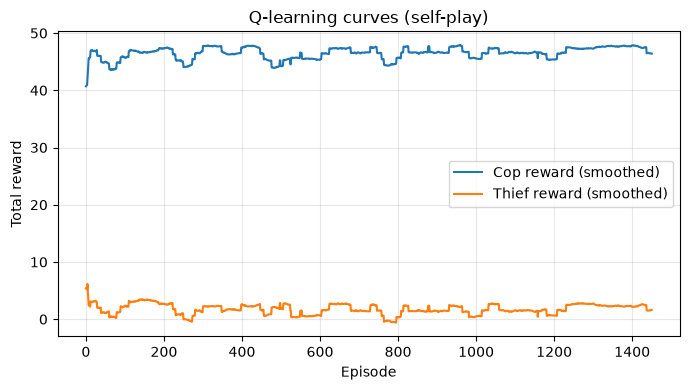

In [2]:
from robocop_mcp.learning.trainer import train
_, _, hist = train(rules, qcfg, episodes=1500, seed=0)
h = np.array(hist)
plt.figure(figsize=(7, 4))
plt.plot(smooth(h[:, 0]), label="Cop reward (smoothed)")
plt.plot(smooth(h[:, 1]), label="Thief reward (smoothed)")
plt.xlabel("Episode"); plt.ylabel("Total reward")
plt.title("Q-learning curves (self-play)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(ASSETS / "learning_curve.png", dpi=120); plt.show()


## 3. Q-policy vs heuristic baseline

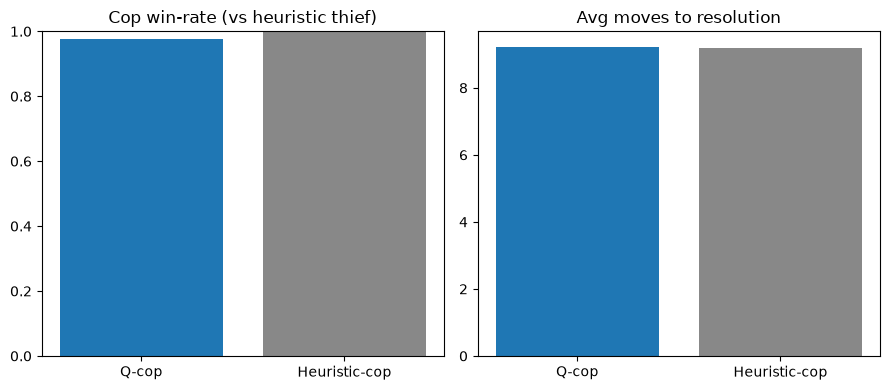

{'cop_win_rate': 0.975, 'avg_moves': 9.225} {'cop_win_rate': 1.0, 'avg_moves': 9.2}


In [3]:
from robocop_mcp.learning.sensitivity import q_vs_heuristic
cmp = q_vs_heuristic(rules, qcfg, episodes=1000, n_eval=80)
labels = ["Q-cop", "Heuristic-cop"]
wr = [cmp["q"]["cop_win_rate"], cmp["heuristic"]["cop_win_rate"]]
mv = [cmp["q"]["avg_moves"], cmp["heuristic"]["avg_moves"]]
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].bar(labels, wr, color=["#1f77b4", "#888"]); ax[0].set_ylim(0, 1)
ax[0].set_title("Cop win-rate (vs heuristic thief)")
ax[1].bar(labels, mv, color=["#1f77b4", "#888"]); ax[1].set_title("Avg moves to resolution")
plt.tight_layout(); plt.savefig(ASSETS / "q_vs_heuristic.png", dpi=120); plt.show()
print(cmp["q"], cmp["heuristic"])


## 4. One-at-a-time parameter sensitivity

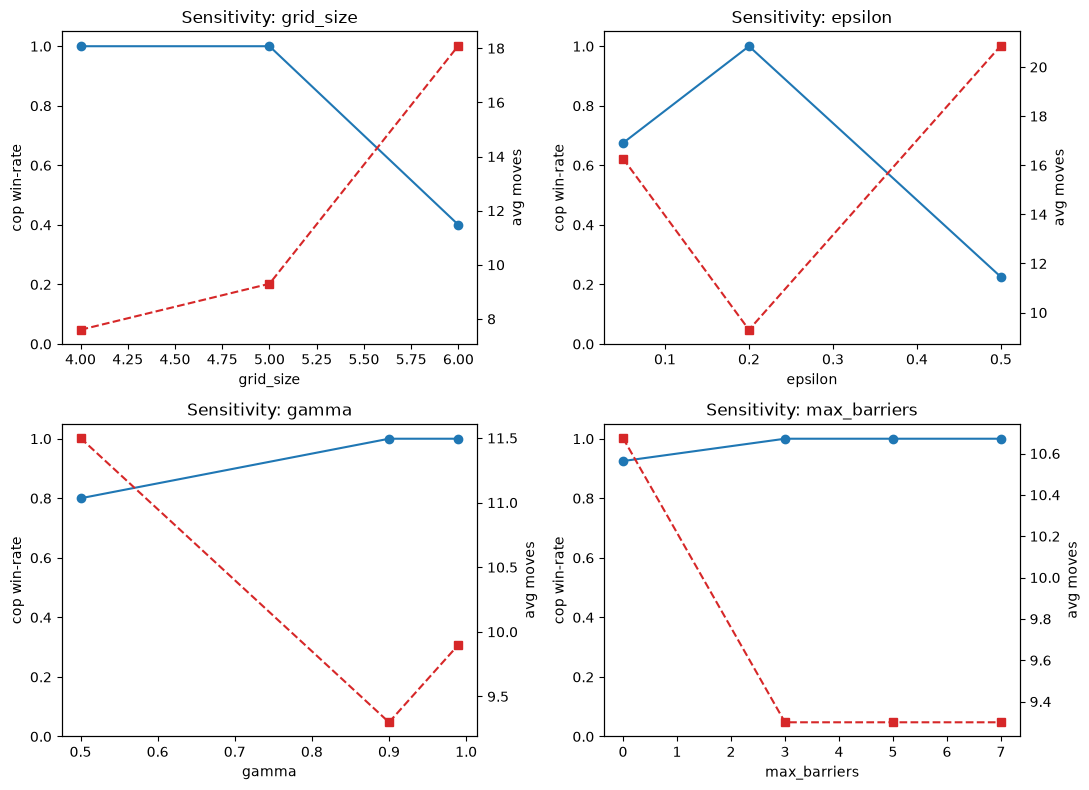

In [4]:
from robocop_mcp.learning.sensitivity import sensitivity_oat
base = cfg.game()
experiments = {"grid_size": [4, 5, 6], "epsilon": [0.05, 0.2, 0.5],
               "gamma": [0.5, 0.9, 0.99], "max_barriers": [0, 3, 5, 7]}
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (param, vals) in zip(axes.ravel(), experiments.items()):
    res = sensitivity_oat(param, vals, base, qcfg, episodes=300, n_eval=40)
    xs = list(res); wr = [res[v]["cop_win_rate"] for v in xs]; mv = [res[v]["avg_moves"] for v in xs]
    ax.plot(xs, wr, "o-", color="#1f77b4"); ax.set_ylim(0, 1.05)
    ax.set_title(f"Sensitivity: {param}"); ax.set_xlabel(param); ax.set_ylabel("cop win-rate")
    ax2 = ax.twinx(); ax2.plot(xs, mv, "s--", color="#d62728"); ax2.set_ylabel("avg moves")
plt.tight_layout(); plt.savefig(ASSETS / "sensitivity.png", dpi=120); plt.show()


## 5. Observation sensitivity (vision_radius)

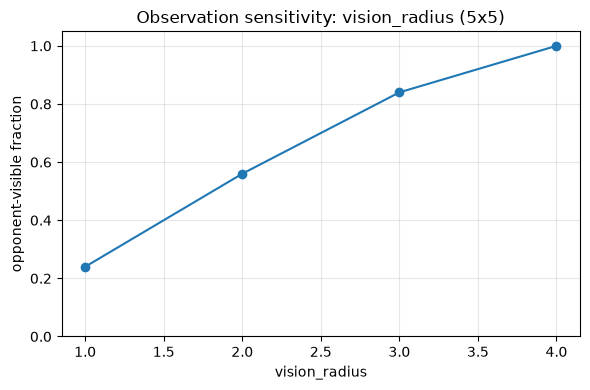

In [5]:
from robocop_mcp.learning.experiments import visibility_coverage
radii = [1, 2, 3, 4]; cov = [visibility_coverage(5, 5, r) for r in radii]
plt.figure(figsize=(6, 4)); plt.plot(radii, cov, "o-"); plt.ylim(0, 1.05)
plt.xlabel("vision_radius"); plt.ylabel("opponent-visible fraction")
plt.title("Observation sensitivity: vision_radius (5x5)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(ASSETS / "vision_coverage.png", dpi=120); plt.show()


## 6. Token-cost analysis (rubric §10)

solo : {'api_calls': 298, 'input_tokens': 40175, 'output_tokens': 6873, 'cost_usd': 0.07454}
bonus: {'api_calls': 386, 'input_tokens': 51967, 'output_tokens': 8756, 'cost_usd': 0.095747}
total: {'api_calls': 684, 'input_tokens': 92142, 'output_tokens': 15629, 'cost_usd': 0.170287}


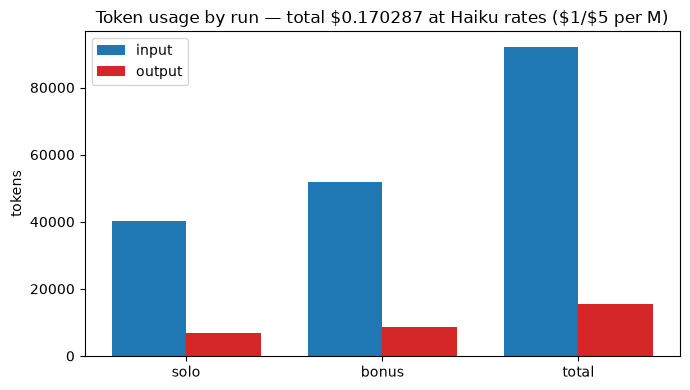

In [6]:
import json
# Real per-run costs live in each run's summary.json. WHY not events.jsonl: the
# committed event stream is trimmed and omits the api_call token records, so mining
# it would under-count to zero — summary.json is the authoritative cost source. §10.
def _cost(name):
    return json.loads((ROOT / "results" / name / "summary.json").read_text())["cost"]
solo, bonus = _cost("solo_demo"), _cost("bonus_demo")
total = {k: round(solo[k] + bonus[k], 6) for k in solo}
print("solo :", solo); print("bonus:", bonus); print("total:", total)
runs = ["solo", "bonus", "total"]
ins = [solo["input_tokens"], bonus["input_tokens"], total["input_tokens"]]
outs = [solo["output_tokens"], bonus["output_tokens"], total["output_tokens"]]
x = np.arange(len(runs)); w = 0.38
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w / 2, ins, w, label="input", color="#1f77b4")
ax.bar(x + w / 2, outs, w, label="output", color="#d62728")
ax.set_xticks(x); ax.set_xticklabels(runs); ax.set_ylabel("tokens"); ax.legend()
ax.set_title(f"Token usage by run — total ${total['cost_usd']} at Haiku rates ($1/$5 per M)")
plt.tight_layout(); plt.savefig(ASSETS / "token_cost.png", dpi=120); plt.show()


## 7. Strategic barriers — PBRS A/B ablation (ADR-0004)

Four Cop variants vs a heuristic Thief from cornering starts: baseline, PBRS-only,
enrichment-only, and PBRS+enrichment+curriculum. **Honest result:** PBRS is
policy-invariant (Ng-Harada-Russell), so *shaping-only matches the baseline exactly*
and adds **no** barrier use — on an open 5x5, walling (which forfeits a move) is
genuinely suboptimal, so a correct learner never places barriers (no reward-hacking).
The escape-bucket state enrichment *fragments* the table and hurts capture. The
barrier mechanic itself is shown in `results/barrier_demo/` (a constructed cornering
scenario): the Cop walls a cornered Thief's escape (escapes 3->2) and captures.

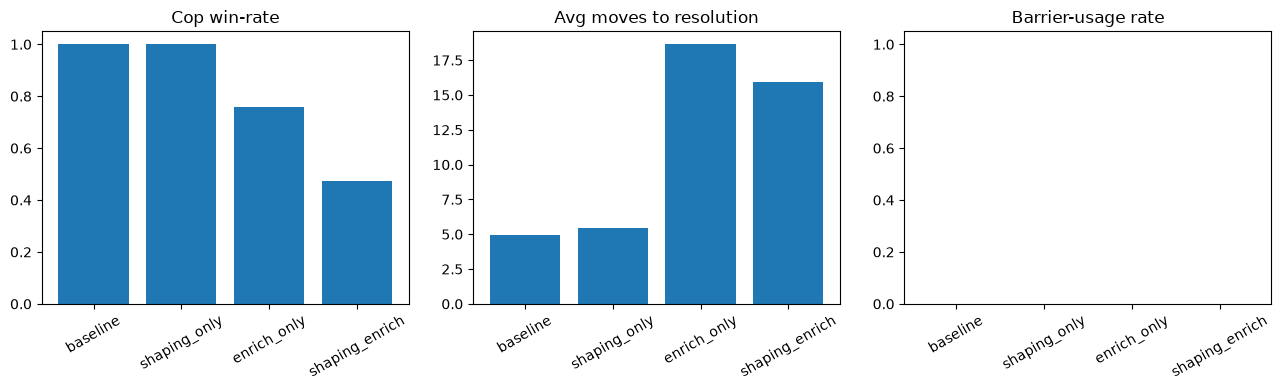

{
  "baseline": {
    "cop_win_rate": 1.0,
    "avg_moves": 4.95,
    "barrier_use_rate": 0.0
  },
  "shaping_only": {
    "cop_win_rate": 1.0,
    "avg_moves": 5.42,
    "barrier_use_rate": 0.0
  },
  "enrich_only": {
    "cop_win_rate": 0.76,
    "avg_moves": 18.64,
    "barrier_use_rate": 0.0
  },
  "shaping_enrich": {
    "cop_win_rate": 0.475,
    "avg_moves": 15.965,
    "barrier_use_rate": 0.0
  }
}


In [7]:
import json
from robocop_mcp.learning.ab_barriers import ab_compare
abp = ROOT / "results" / "qtables_advanced" / "ab_barriers.json"
ab = json.loads(abp.read_text()) if abp.exists() else ab_compare(rules, qcfg, n_eval=150)
variants = list(ab)
metrics = [("cop_win_rate", "Cop win-rate", (0, 1.05)),
           ("avg_moves", "Avg moves to resolution", None),
           ("barrier_use_rate", "Barrier-usage rate", (0, 1.05))]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (key, title, ylim) in zip(axes, metrics):
    ax.bar(variants, [ab[v][key] for v in variants], color="#1f77b4")
    ax.set_title(title); ax.tick_params(axis="x", rotation=30)
    if ylim: ax.set_ylim(*ylim)
plt.tight_layout(); plt.savefig(ASSETS / "barrier_ab.png", dpi=120); plt.show()
print(json.dumps(ab, indent=2))
